In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from sklearn.cluster import KMeans
from sklearn import svm
from sklearn.inspection import DecisionBoundaryDisplay

sys.path.append('C:\\Users\\Mark\\PycharmProjects\\approximationMap')

from control.experiment_data import ExperimentData
ex = ExperimentData()

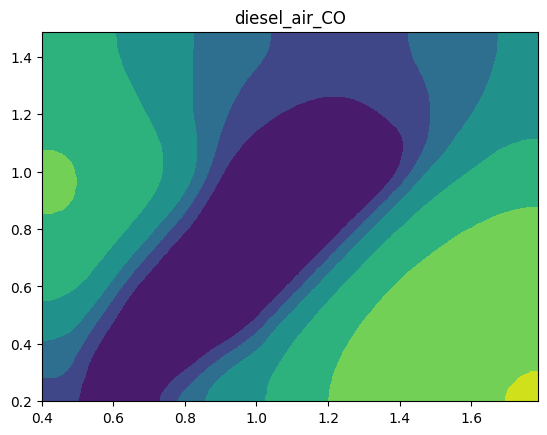

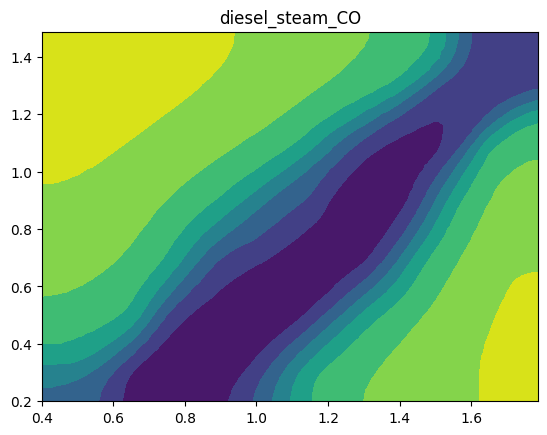

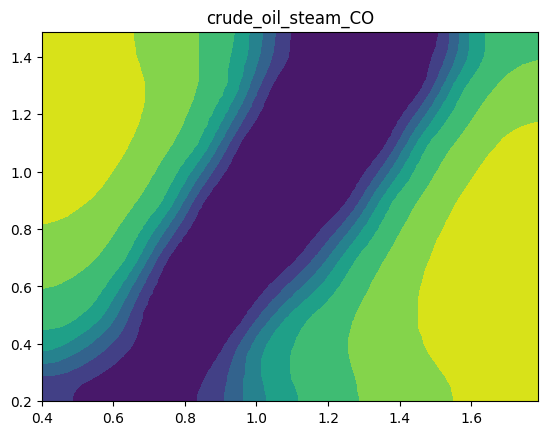

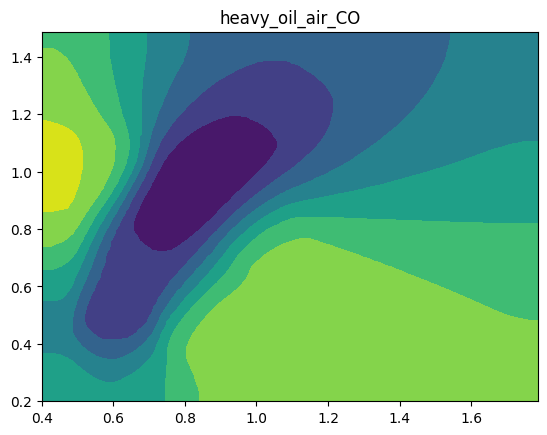

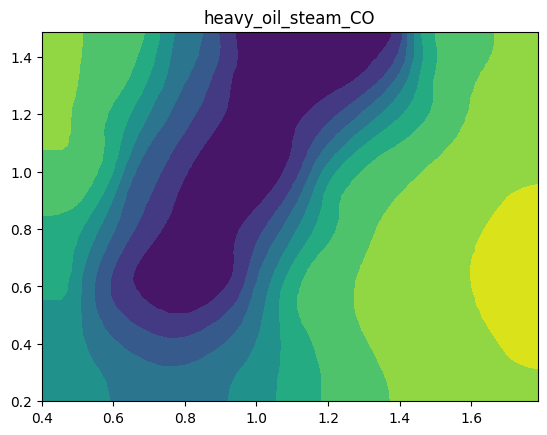

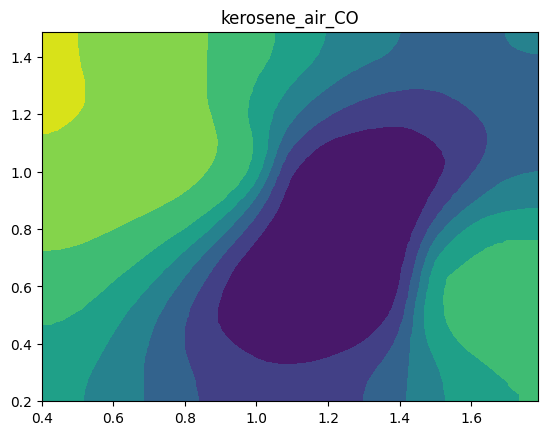

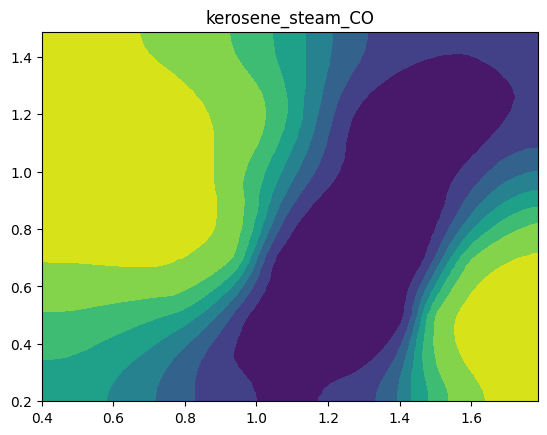

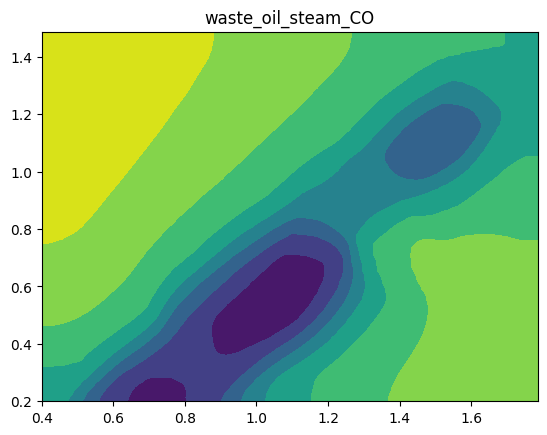

In [2]:
variants = ex.get_all_available_variations()

surfs = {}

for var in [var for var in variants if var[2] == 'CO']:
    name = '_'.join(var)
    ex.get_experiment_data(*var)
    fuel, add, surface = ex.get_rbf_data()
    surfs[name] = fuel, add, surface
    plt.title(name)
    plt.contourf(fuel, add, surface)
    plt.show()
    plt.close()

diesel_air_CO


C:\Users\Mark\AppData\Local\Temp\ipykernel_6496\4185039682.py:12: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[4]


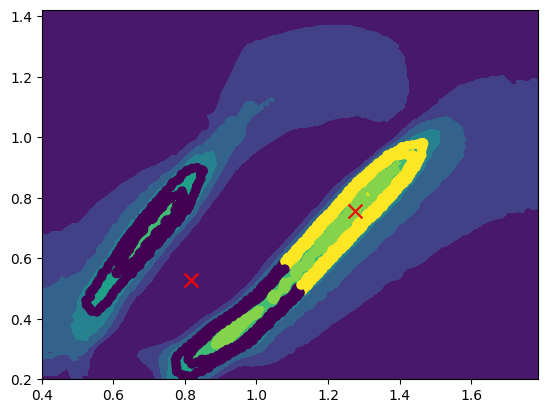

diesel_steam_CO


C:\Users\Mark\AppData\Local\Temp\ipykernel_6496\4185039682.py:12: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[4]


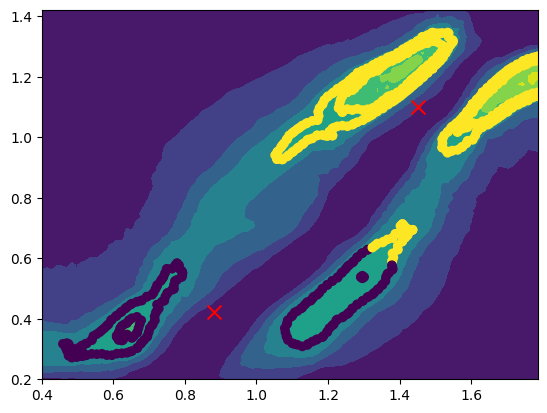

crude_oil_steam_CO


C:\Users\Mark\AppData\Local\Temp\ipykernel_6496\4185039682.py:12: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[4]


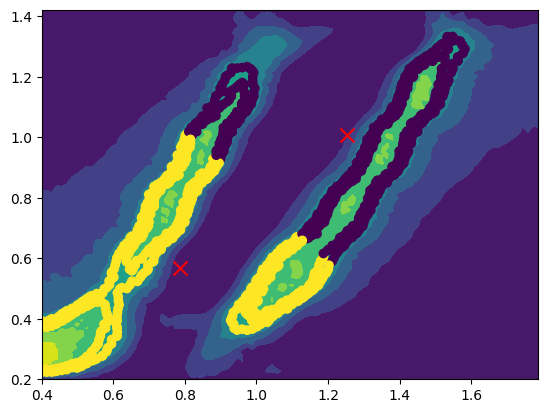

heavy_oil_air_CO


C:\Users\Mark\AppData\Local\Temp\ipykernel_6496\4185039682.py:12: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[4]


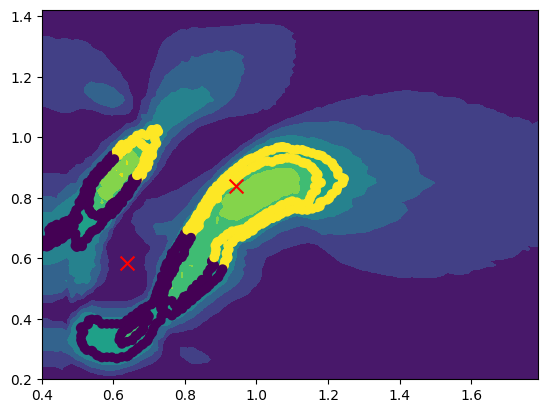

C:\Users\Mark\AppData\Local\Temp\ipykernel_6496\4185039682.py:12: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[4]


heavy_oil_steam_CO


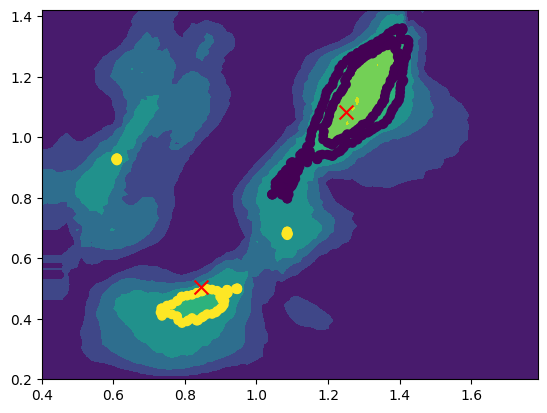

kerosene_air_CO


C:\Users\Mark\AppData\Local\Temp\ipykernel_6496\4185039682.py:12: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[4]


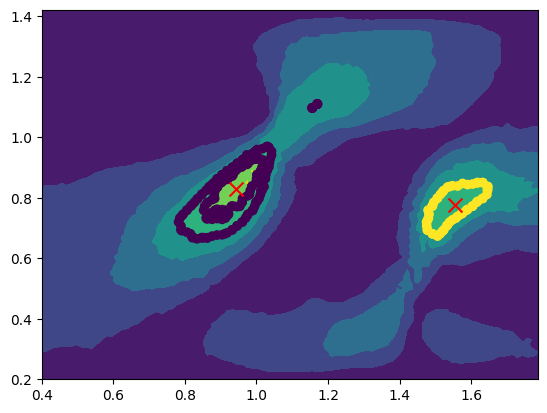

kerosene_steam_CO


C:\Users\Mark\AppData\Local\Temp\ipykernel_6496\4185039682.py:12: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[4]


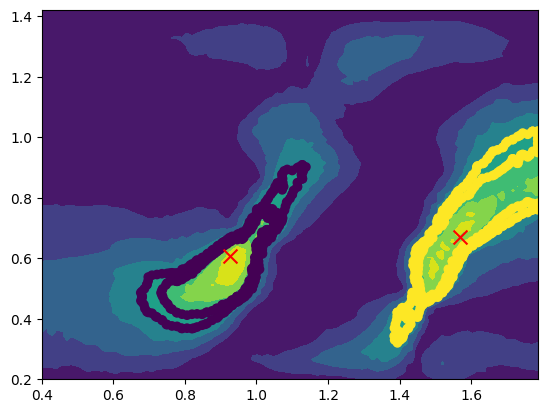

waste_oil_steam_CO


C:\Users\Mark\AppData\Local\Temp\ipykernel_6496\4185039682.py:12: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[4]


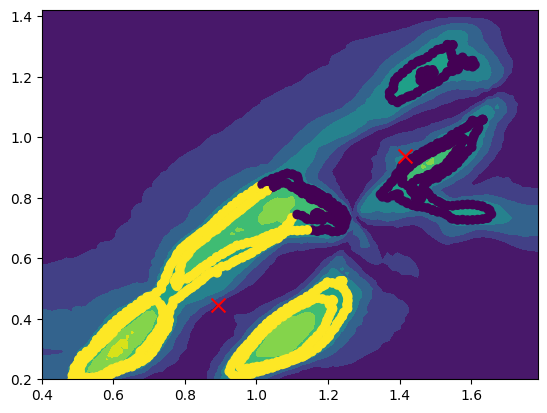

In [8]:
diffs = {}

for name in surfs:
    print(name)
    surf = surfs[name][2]
    diff = np.abs(surf[5:] - surf[:-5])
    surf = surf[5:]
    x = surfs[name][0]
    y = surfs[name][1][5:]
    
    contours = plt.contourf(x, y, diff)
    selected_contour = contours.collections[4]
    path = selected_contour.get_paths()[0]
    points = path.vertices

    kmeans = KMeans(n_clusters=2)
    kmeans.fit(points)
    
    cluster_centers = kmeans.cluster_centers_

    plt.scatter(points[:, 0], points[:, 1], c=kmeans.labels_, cmap='viridis')
    plt.scatter(cluster_centers[:, 0], cluster_centers[:, 1], marker='x', c='red', s=100)  # Центры кластеров
    
    c_x, x_y = points[:, 0], points[:, 1]
    #plt.scatter(c_x, x_y, c='black')
    plt.show()
    plt.close()

C:\Users\Mark\AppData\Local\Temp\ipykernel_6496\4010002772.py:46: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[3]


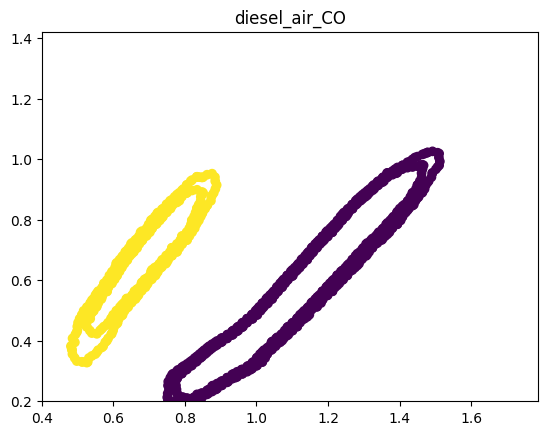

C:\Users\Mark\AppData\Local\Temp\ipykernel_6496\4010002772.py:46: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[3]


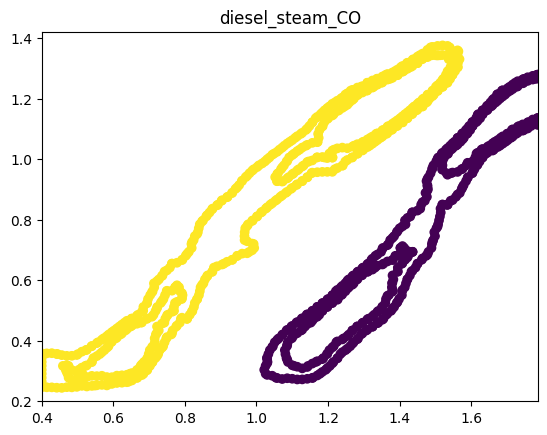

C:\Users\Mark\AppData\Local\Temp\ipykernel_6496\4010002772.py:46: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[3]


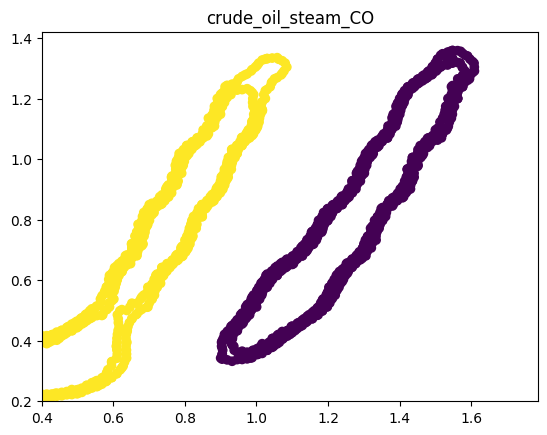

C:\Users\Mark\AppData\Local\Temp\ipykernel_6496\4010002772.py:46: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[3]


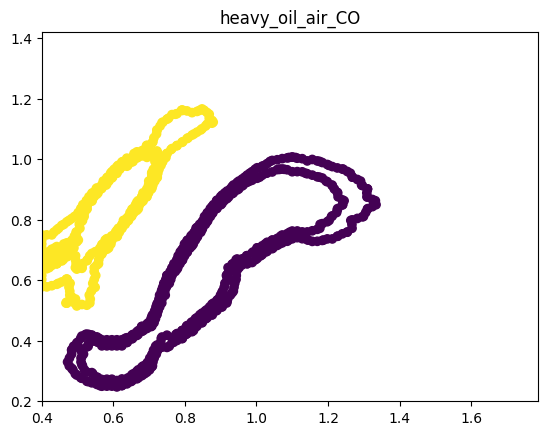

C:\Users\Mark\AppData\Local\Temp\ipykernel_6496\4010002772.py:46: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[3]


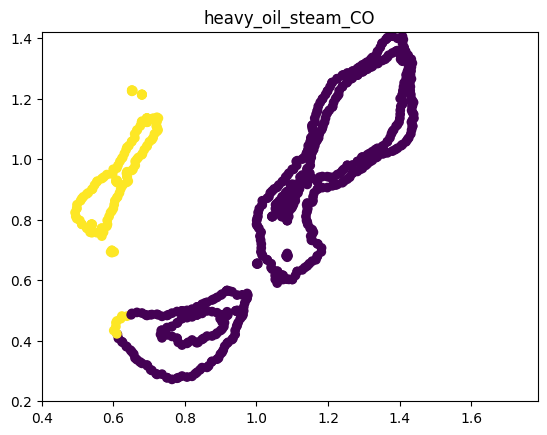

C:\Users\Mark\AppData\Local\Temp\ipykernel_6496\4010002772.py:46: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[3]


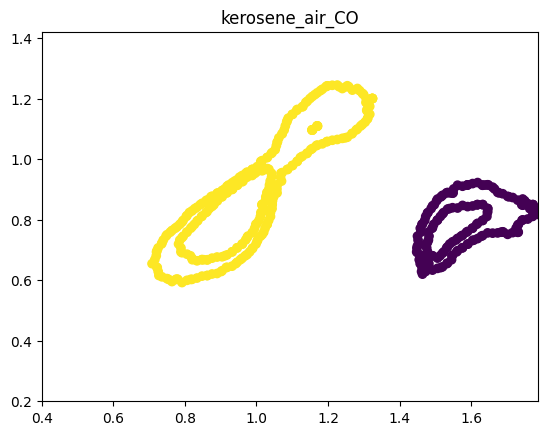

C:\Users\Mark\AppData\Local\Temp\ipykernel_6496\4010002772.py:46: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[3]


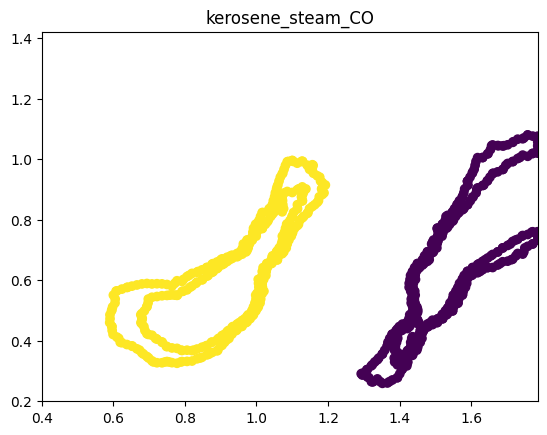

C:\Users\Mark\AppData\Local\Temp\ipykernel_6496\4010002772.py:46: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[3]


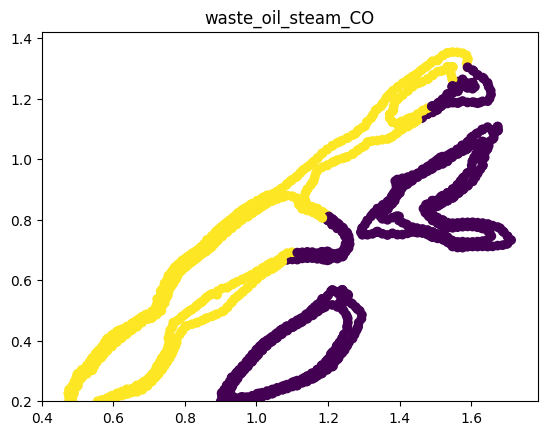

In [28]:
models = {}

train = {
    'diesel_air_CO': (
        [[1.4, 1], [0.8, 0.22], [0.7, 0.82], [0.6, 0.6]], 
        [0, 0, 1, 1]
    ),
    'diesel_steam_CO': (
        [[1.6, 1], [1.2, 0.4], [1.4, 1.2], [0.6, 0.4]], 
        [0, 0, 1, 1]
    ),
    'crude_oil_steam_CO': (
        [[1.5, 1.2], [1.1, 0.6], [0.9, 1.1], [0.4, 0.2], [1, 1.25]], 
        [0, 0, 1, 1, 1]
    ),
    'heavy_oil_air_CO': (
        [[1.2, 1], [0.6, 0.3], [0.7, 1], [0.5, 0.75]], 
        [0, 0, 1, 1]
    ),
    'heavy_oil_steam_CO': (
        [[1.4, 1.3], [1.2, 1], [0.8, 1.0], [1, 1.4]], 
        [0, 0, 1, 1]
    ),
    'kerosene_air_CO': (
        [[1.6, 0.8], [1.2, 0.3], [1.4, 1.4], [0.4, 0.4]], 
        [0, 0, 1, 1]
    ),
    'kerosene_steam_CO': (
        [[1.6, 1], [1.4, 0.3], [1.2, 1.0], [0.8, 0.4]], 
        [0, 0, 1, 1]
    ),
    'waste_oil_steam_CO': (
        [[1, 0.25], [1.6, 1], [0.6, 0.2], [1.4, 1.2]], 
        [0, 0, 1, 1]
    ),
}

for name in surfs:
    surf = surfs[name][2]
    diff = np.abs(surf[5:] - surf[:-5])
    surf = surf[5:]
    x = surfs[name][0]
    y = surfs[name][1][5:]

    contours = plt.contourf(x, y, diff, colors='none')
    selected_contour = contours.collections[3]
    path = selected_contour.get_paths()[0]
    points = path.vertices
    
    x_train, y_train = train[name]
    clf = svm.LinearSVC(dual="auto").fit(x_train, y_train)
    x_test = [list(sample) for sample in zip(points[:, 0], points[:, 1])]
    clf_pred = clf.predict(x_test)
    
    #plt.contourf(x, surfs[name][1], surfs[name][2])
    plt.scatter(points[:, 0], points[:, 1], c=clf_pred)
    plt.title(name)
    
    plt.show()
    plt.close()


In [29]:
def linear(x, a, b):
    return a * x + b

C:\Users\Mark\AppData\Local\Temp\ipykernel_6496\3054399901.py:9: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[2]


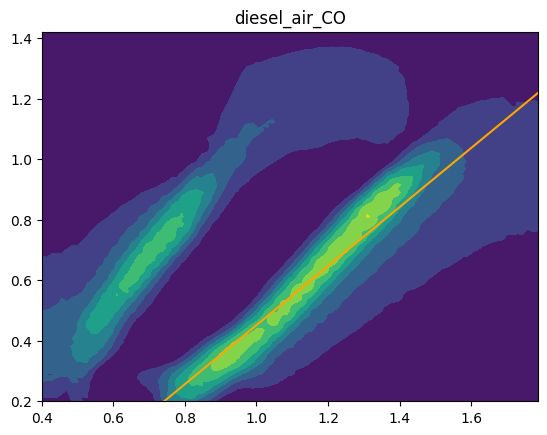

C:\Users\Mark\AppData\Local\Temp\ipykernel_6496\3054399901.py:9: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[2]


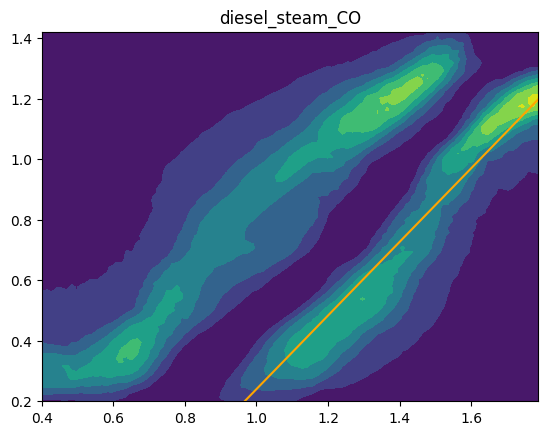

C:\Users\Mark\AppData\Local\Temp\ipykernel_6496\3054399901.py:9: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[2]


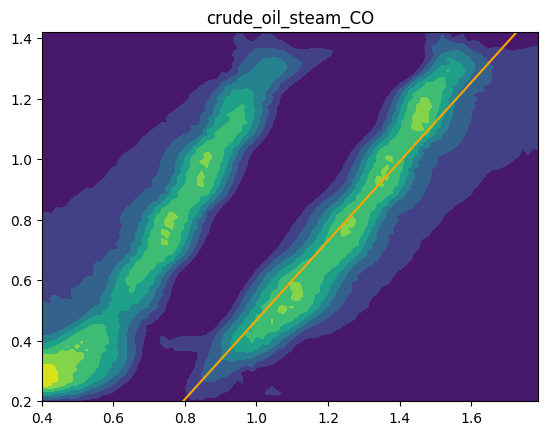

C:\Users\Mark\AppData\Local\Temp\ipykernel_6496\3054399901.py:9: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[2]


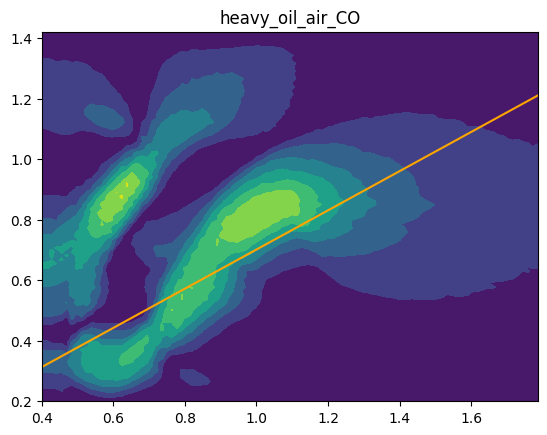

C:\Users\Mark\AppData\Local\Temp\ipykernel_6496\3054399901.py:9: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[2]


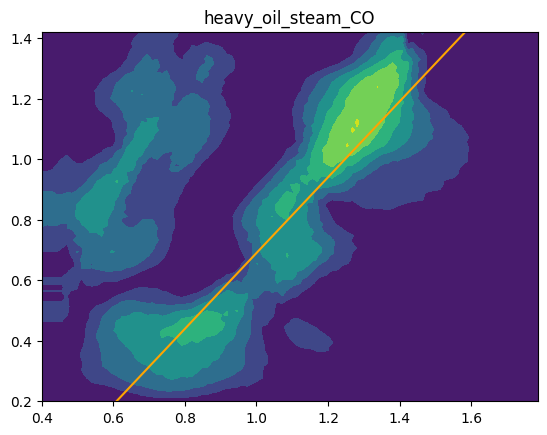

C:\Users\Mark\AppData\Local\Temp\ipykernel_6496\3054399901.py:9: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[2]


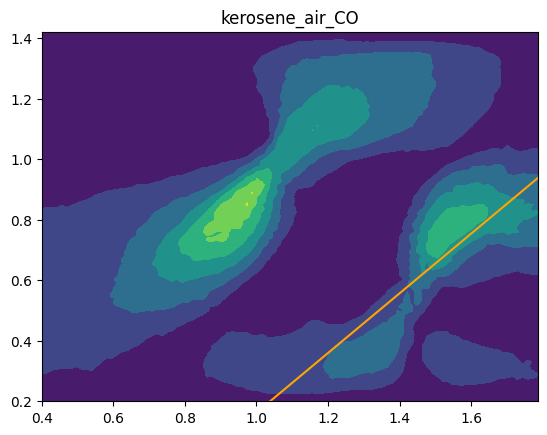

C:\Users\Mark\AppData\Local\Temp\ipykernel_6496\3054399901.py:9: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[2]


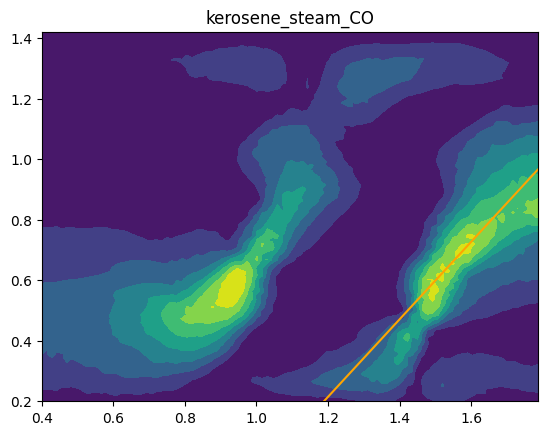

C:\Users\Mark\AppData\Local\Temp\ipykernel_6496\3054399901.py:9: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  selected_contour = contours.collections[2]


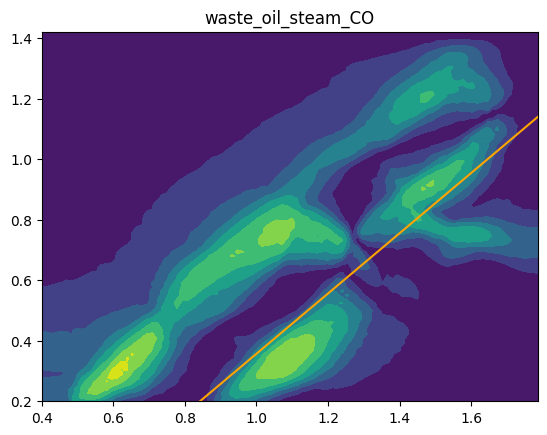

In [30]:
for name in surfs:
    surf = surfs[name][2]
    diff = np.abs(surf[5:] - surf[:-5])
    surf = surf[5:]
    x = surfs[name][0]
    y = surfs[name][1][5:]

    contours = plt.contourf(x, y, diff, colors='none')
    selected_contour = contours.collections[2]
    path = selected_contour.get_paths()[0]
    points = path.vertices
    
    x_train, y_train = train[name]
    clf = svm.LinearSVC(dual="auto").fit(x_train, y_train)
    
    x_test = [list(sample) for sample in zip(points[:, 0], points[:, 1])]
    clf_pred = clf.predict(x_test)

    df = pd.DataFrame({'x': points[:, 0], 'y': points[:, 1], 'pred': clf_pred})
    df = df.loc[df['pred'] == 0]

    plt.contourf(x, y, diff)
    #plt.contourf(surfs[name][0], surfs[name][1], surfs[name][2])
    #plt.scatter(points[:, 0], points[:, 1], c=clf_pred)

    params, _ = curve_fit(linear, df['x'], df['y'])
    a, b = params

    y_ = linear(x, a, b)
    plt.title(name)

    plt.plot(x, y_, c='orange')
    plt.ylim(min(y), max(y))
    
    plt.show()
    plt.close()